### Plot of dirac delta function with a generator of DDF

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Enter your roll number / 100 in roll_no variable, that will act as x' , by default it is 0.03, which is my rollno. And for number of terms i.e n change in no_of_terms variable which by default is 1000. Run the program from first cell rest program will do the job. 

### Sine function defined

In [2]:
def sine(n,roll):
    return np.sin(n * np.pi * roll)

Setting up the calculation for x = x'

In [ ]:
# variables
roll = 0.5
roll_no = 0.03
no_of_terms = 1000
n = [i for i in range(1, no_of_terms + 1)]
y_pos_for_title = 1.02


In [ ]:

y = [2*sine(i, roll_no)* sine(i,roll_no) for i in n]
y = np.array(y)
cum_sum = np.cumsum(y)


### Plot for same i.e x=x' case

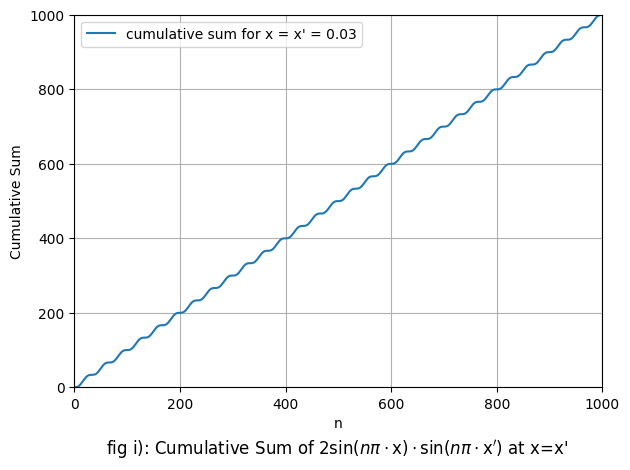

In [101]:
plt.plot(n, cum_sum, label='cumulative sum for roll=0.5')
plt.xlabel('n')
plt.ylabel('Cumulative Sum')
plt.title(r"fig i): Cumulative Sum of $2\sin(n\pi \cdot \mathrm{x}) \cdot \sin(n\pi \cdot \mathrm{x'})$ at x=x' ", y=y_pos_for_title) 
plt.xlim(0, no_of_terms)
plt.ylim(0, np.max(cum_sum)+0.5)
plt.legend([f"cumulative sum for x = x' = {roll_no}"])
plt.grid()
plt.tight_layout()
plt.savefig('figs/x_equals_xdash_plot.png', bbox_inches='tight', pad_inches=0.2)


Plot for x != x' 

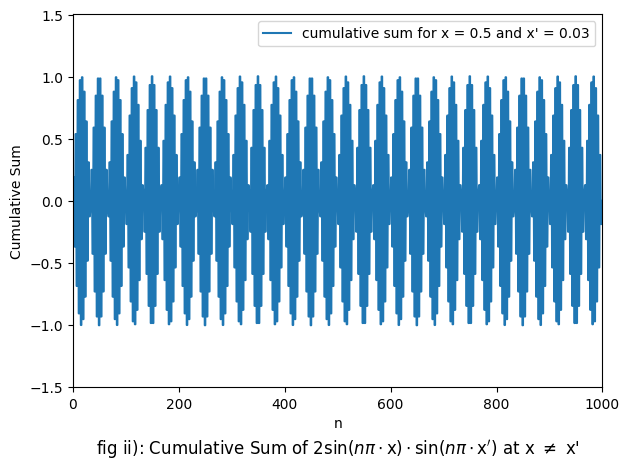

In [100]:
y_diff = np.array([2*sine(i, roll)* sine(i,roll_no) for i in n])
cum_diff = np.cumsum(y_diff)
plt.plot(n, cum_diff, label='CF with x=0.5 and x\'=0.03')
plt.xlim(0, no_of_terms)
plt.ylim(np.min(cum_diff)-0.5, np.max(cum_diff)+0.5)
plt.title(r"fig ii): Cumulative Sum of $2\sin(n\pi \cdot \mathrm{x}) \cdot \sin(n\pi \cdot \mathrm{x'})$ at x $\neq$ x'", y=y_pos_for_title)
plt.xlabel('n')
plt.ylabel('Cumulative Sum')
plt.legend([f"cumulative sum for x = {roll} and x' = {roll_no}"])
plt.tight_layout()
plt.savefig('figs/x_notequals_xdash_roll_plot.png', bbox_inches='tight', pad_inches=0.2)
plt.show()

In [50]:
np.min(cum_diff), np.max(cum_diff)
# index fo min and max values
min_index = np.argmin(cum_diff)
max_index = np.argmax(cum_diff)
all_max = np.where(cum_diff == np.max(cum_diff))[0]
all_min = np.where(cum_diff == np.min(cum_diff))[0]
all_max, all_min

(array([949]), array([849]))

### The ultimate dirac delta function plot

In [84]:
x_dash = 0.03
N1 = min_index  # Using the index of the minimum value as N1
N2 = max_index  # Using the index of the maximum value as N2
N1 = 20
N2 = 200
# for N1
x = np.linspace(0, 1, 1000)
n1 = np.arange(1, N1 + 1)[:, np.newaxis]
terms1 = 2 * np.sin(n1 * np.pi * x) * np.sin(n1 * np.pi * x_dash)
ddf1 = np.sum(terms1, axis=0)

# for N2
n2 = np.arange(1, N2 + 1)[:, np.newaxis]
terms2 = 2 * np.sin(n2 * np.pi * x) * np.sin(n2 * np.pi * x_dash)
ddf2 = np.sum(terms2, axis=0)


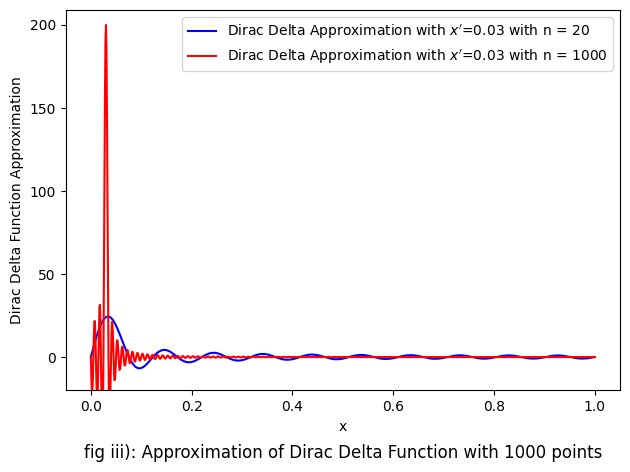

In [99]:
plt.plot(x, ddf1,color='blue', label=f'Dirac Delta Approximation with $x\'$={x_dash} with n = {N1}')
plt.plot(x, ddf2, color='red', label=f'Dirac Delta Approximation with $x\'$={x_dash} with n = {N2}')
plt.ylim(-20, int(np.max((ddf1,ddf2)) + 10))
plt.xlabel('x')
plt.ylabel('Dirac Delta Function Approximation')
plt.title('fig iii): Approximation of Dirac Delta Function with 1000 points', y = y_pos_for_title)
plt.legend()
plt.tight_layout()
plt.savefig('figs/dirac_delta_approximation_plot.png', bbox_inches='tight', pad_inches=0.2)


In [61]:
ddf2.size, ddf2.shape
np.max([np.max(ddf1), np.max(ddf2)])


np.float64(199.88838541765446)

### Area under the delta curve

In [86]:
np.trapezoid(ddf1, x), np.trapezoid(ddf2, x)

(np.float64(0.9872257730178844), np.float64(0.9674826637023449))

### This is for Fourier convergence the following two cells areirrelevent of our DDF practical, directly jump to Integrate part

Text(0.5, 1.0, 'Convergence of Fourier Series to Dirac Delta Function')

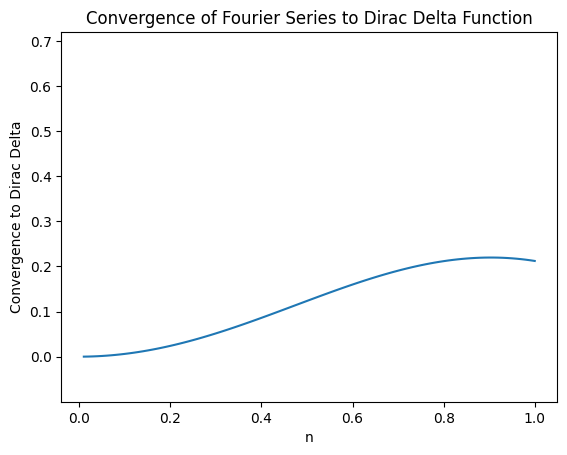

In [ ]:
roll = 0.7
n = np.linspace(0.01, 1, 100)
convg = 2*np.sin(n*np.pi*roll) * ( 1 - np.cos(n*np.pi*0.3) ) / (n * np.pi)
plt.plot(n, convg)
plt.xlabel('n')
plt.ylim(np.min(convg)-0.1, np.max(convg)+0.5)
plt.ylabel('Convergence to Dirac Delta')
plt.title('Convergence of Fourier Series to Dirac Delta Function')


In [1]:
# Parameters
x_dash = 0.03
N_values = [10, 50, 200]
x = np.linspace(0, 1, 1000)

def delta_integral(x_arr, x_p, N):
    """Vectorized calculation of the integral sum."""
    n = np.arange(1, N + 1)[:, np.newaxis]
    # The integral of 2*sin(n*pi*y)*sin(n*pi*x') from 0 to x
    terms = (2 * np.sin(n * np.pi * x_p) * (1 - np.cos(n * np.pi * x_arr))) / (n * np.pi)
    return np.sum(terms, axis=0)

# Plotting the Step Function behavior
plt.figure(figsize=(10, 5))
for N in N_values:
    y_int = delta_integral(x, x_dash, N)
    plt.plot(x, y_int, label=f'N={N}')

# plt.axvline(x_dash, color='k', linestyle='--', alpha=0.5, label="x' = 0.3")
# plt.axhline(0, color='gray', linestyle=':')
# plt.axhline(1, color='gray', linestyle=':')
plt.title("Convergence to Step Function (0 and 1)")
plt.xlabel("x")
plt.ylabel("Value of $\int_0^x \delta_N(y, x') dy$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/convergence.png', bbox_inches='tight', pad_inches=0.2)
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\i'
<>:24: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_140745/1310183386.py:24: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel("Value of $\int_0^x \delta_N(y, x') dy$")
/tmp/ipykernel_140745/1310183386.py:24: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel("Value of $\int_0^x \delta_N(y, x') dy$")


NameError: name 'np' is not defined

### Integrate the function in three different regions
1. from 0 to x' - 0.01 , where it converges to zero as x' doesn't lies within the integration range.
2. from x'-0.01 to x' + 0.01 , where it converges to 1 as x' lies within the range
3. from x' + 0.01 to 1 , where it again converges to 0

In [87]:
# integration of the Dirac Delta function approximation

def get_delta_integral_terms(a, b, x_dash, N):
    """
    Returns an array of the individual terms of the integral sum for n=1 to N.
    """
    n = np.arange(1, N + 1)
    # Using the analytical integral formula
    terms = (2 * np.sin(n * np.pi * x_dash) * (np.cos(n * np.pi * a) - np.cos(n * np.pi * b))) / (n * np.pi)
    return terms

In [88]:
# Define the three regions
regions = [
    (0, x_dash - 0.01, "Region 1: [0, 0.02] (Misses Spike)", "red", 0),
    (x_dash - 0.01, x_dash + 0.01, "Region 2: [0.02, 0.04] (Contains Spike)", "green", 1),
    (x_dash + 0.01, 1.0, "Region 3: [0.04, 1.0] (Misses Spike)", "blue", 0)
]

### First case i.e from 0 to x'-0.01

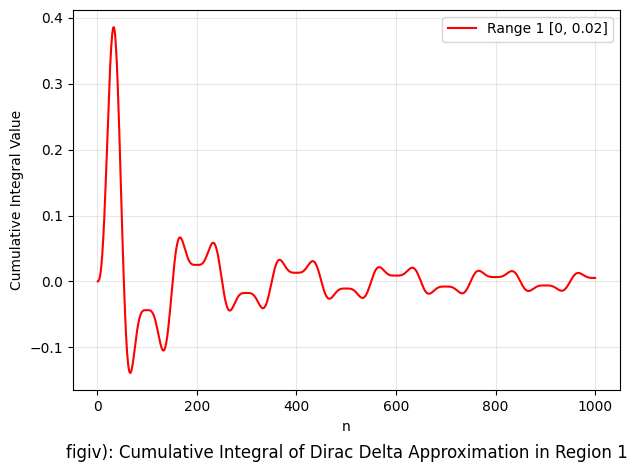

In [98]:
a1 , b1 = regions[0][0], regions[0][1]
N2 = 1000
terms_region1 = get_delta_integral_terms(a1, b1, x_dash, no_of_terms)
cumulative_integral = np.cumsum(terms_region1)
plt.plot(np.arange(1, N2 + 1), cumulative_integral, label=regions[0][2], color=regions[0][3])
plt.xlabel('n')
plt.ylabel('Cumulative Integral Value')
plt.title('figiv): Cumulative Integral of Dirac Delta Approximation in Region 1', y = y_pos_for_title)
plt.legend([f"Range 1 [{a1}, {b1:0.2f}]"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/region1_integral.png', bbox_inches='tight', pad_inches=0.2)

### Second region

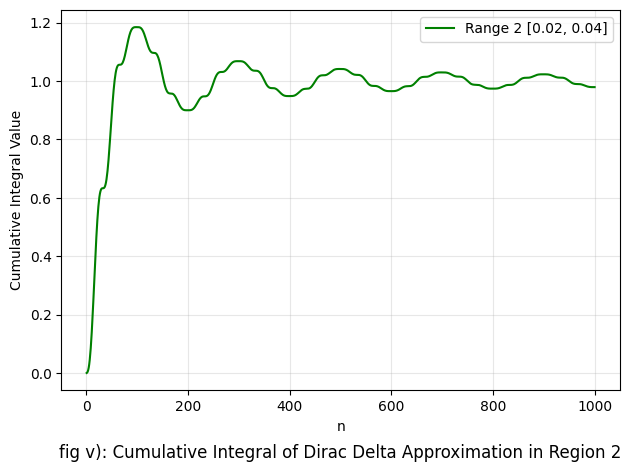

In [97]:
a2, b2 = regions[1][0], regions[1][1]
terms_region2 = get_delta_integral_terms(a2, b2, x_dash, N2)
cumulative_integral = np.cumsum(terms_region2)
plt.plot(np.arange(1, N2 + 1), cumulative_integral, label=regions[1][2], color=regions[1][3])
plt.xlabel('n')
plt.ylabel('Cumulative Integral Value')
plt.title('fig v): Cumulative Integral of Dirac Delta Approximation in Region 2', y = y_pos_for_title)
plt.legend([f"Range 2 [{a2:0.2f}, {b2:0.2f}]"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/region2_integral.png', bbox_inches='tight', pad_inches=0.2)

### Third region

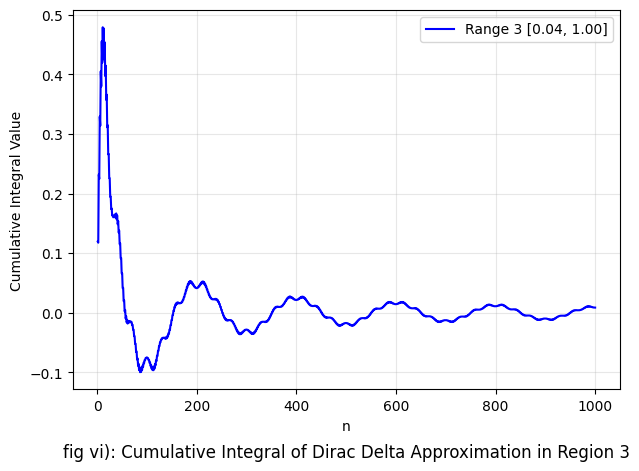

In [96]:
a3, b3 = regions[2][0], regions[2][1]
N2 = 1000
terms_region3 = get_delta_integral_terms(a3, b3, x_dash, N2)
cumulative_integral = np.cumsum(terms_region3)
plt.plot(np.arange(1, N2 + 1), cumulative_integral, label=regions[2][2], color=regions[2][3])
plt.xlabel('n')
plt.ylabel('Cumulative Integral Value')
plt.title('fig vi): Cumulative Integral of Dirac Delta Approximation in Region 3', y = y_pos_for_title)
plt.legend([f"Range 3 [{a3:0.2f}, {b3:0.2f}]"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/region3_integral.png', bbox_inches='tight', pad_inches=0.2)